### EDA

This file contains the code for the EDA which examines the features of the dataset to see any important trends or patterns which may help us later on. In this file we focus on the muerical features as well as the categories and state the projects are funded from. Lastly, we look at the overall distribution of the data itself. 

In [13]:
%run data_prep.ipynb 

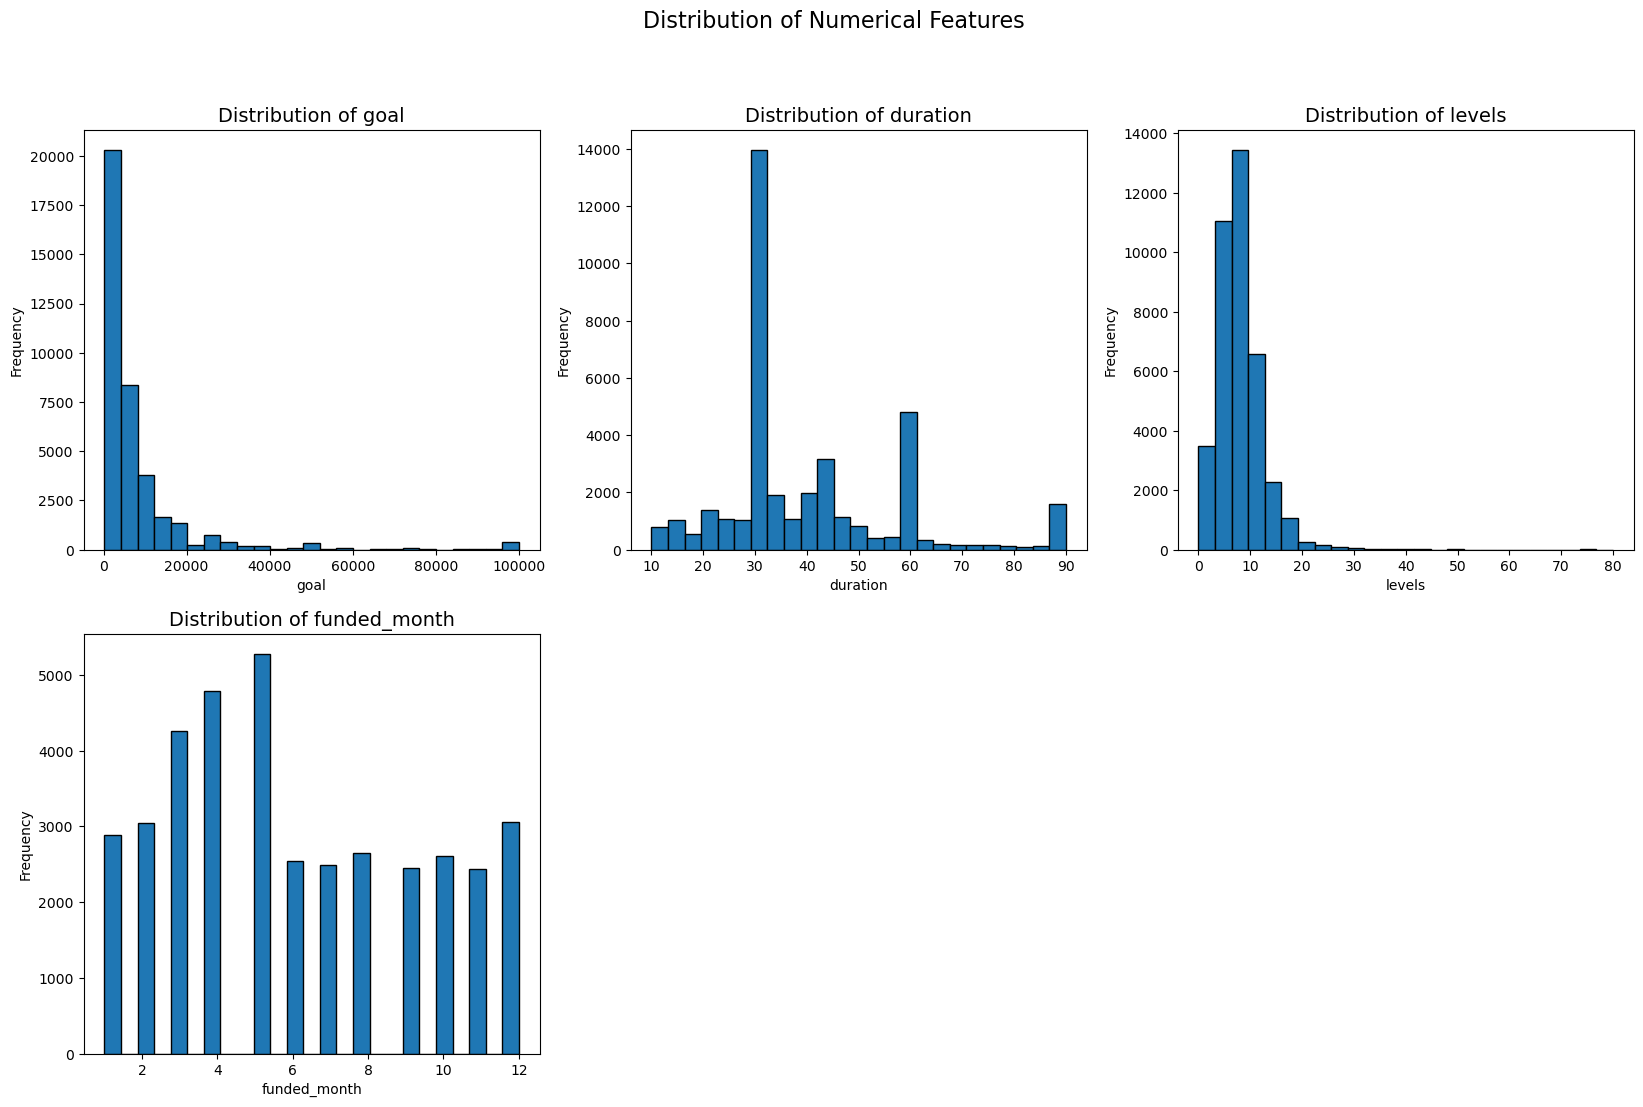

In [14]:
numerical_cols = ['goal', 'duration', 'levels', 'funded_month']
# Histograms to show distributions
plt.figure(figsize=(20, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    plt.hist(df[col], bins=25, edgecolor='black')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.show()

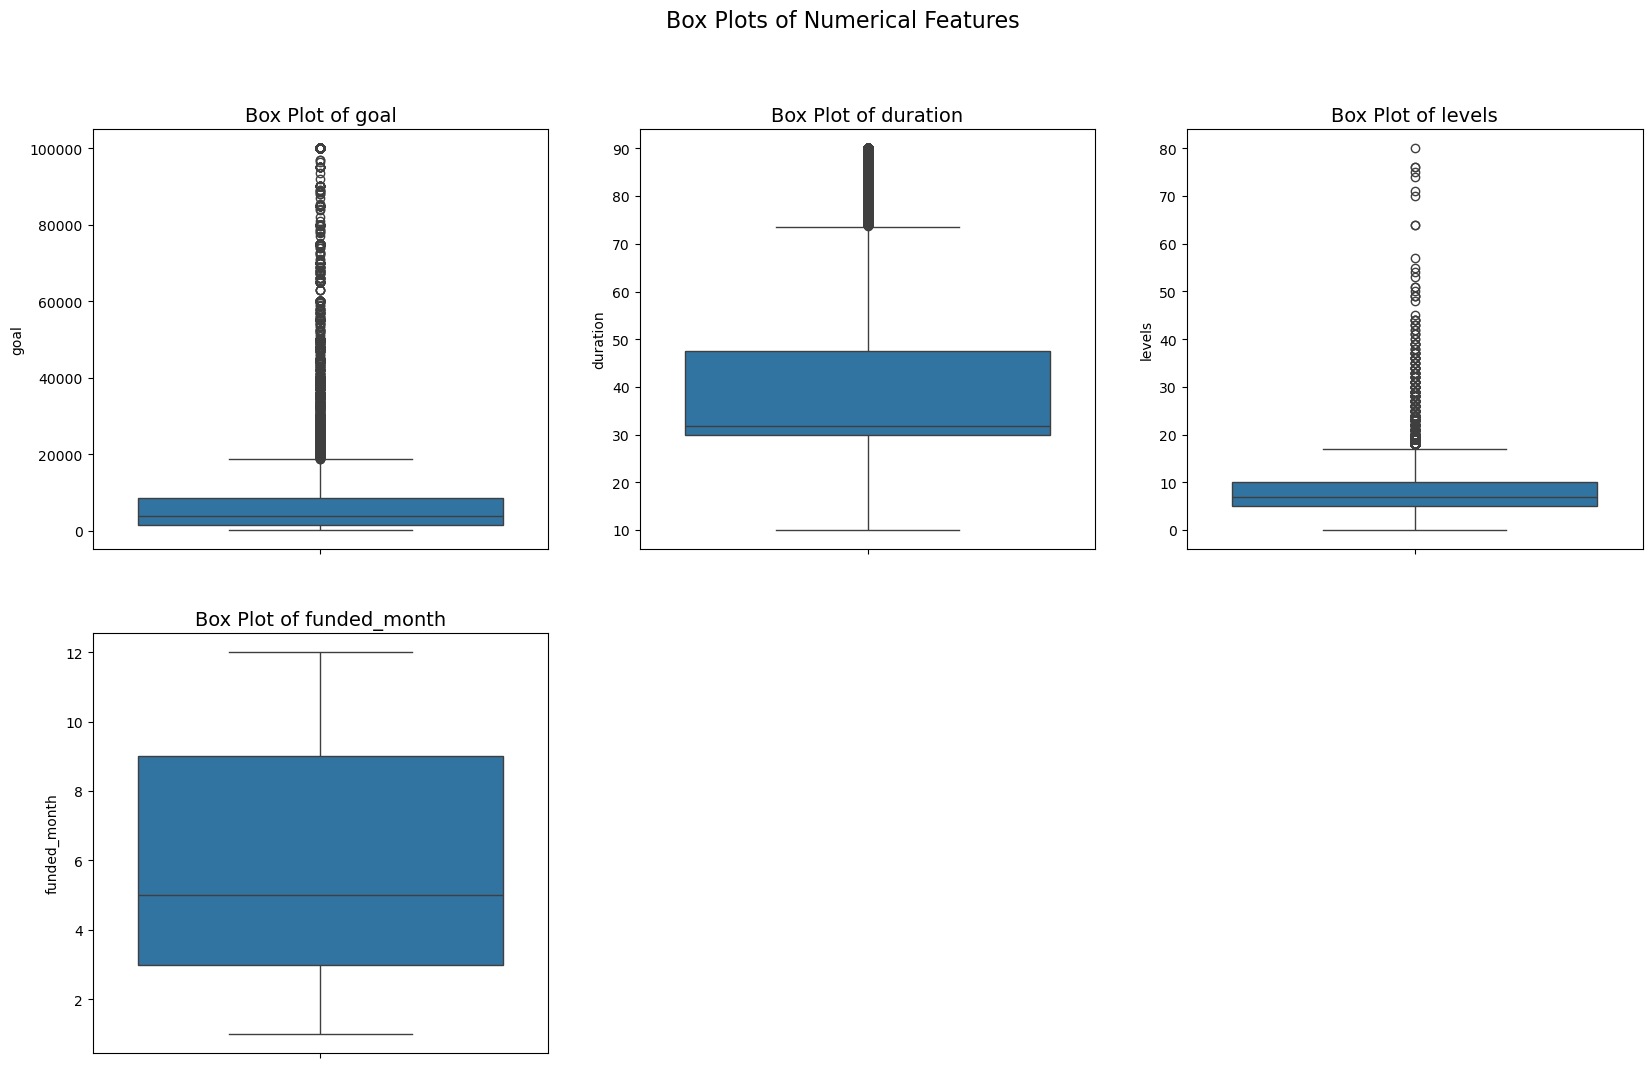

In [15]:
# Box plots to show distribution and outliers
plt.figure(figsize=(20, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}', fontsize=14)
    plt.ylabel(col)

plt.suptitle('Box Plots of Numerical Features', fontsize=16)
plt.show()

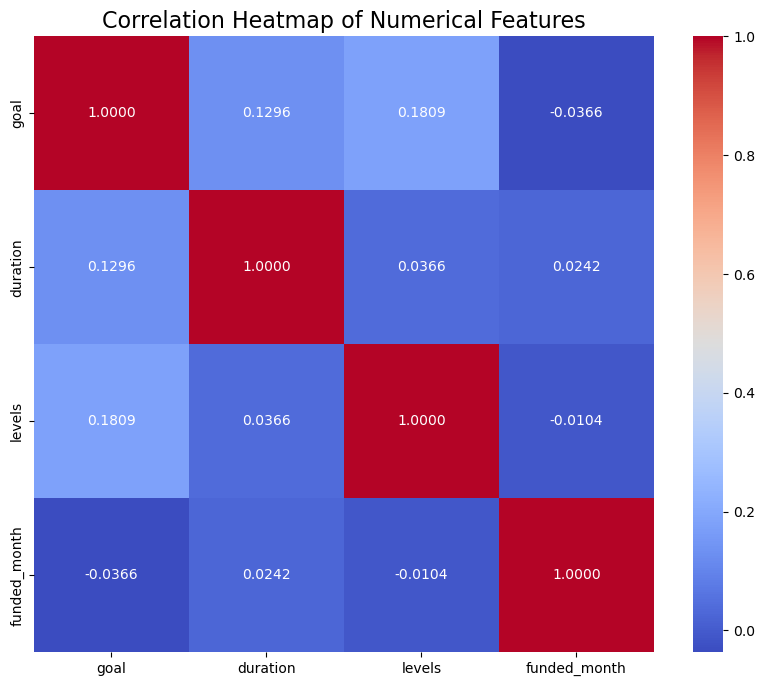

In [16]:
# Correlation Heatmap
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt='.4f')
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

In [17]:
# Category columns
category_cols = [col for col in df.columns if col.startswith('category_')]
category_cols

['category_Comics',
 'category_Dance',
 'category_Design',
 'category_Fashion',
 'category_Film & Video',
 'category_Film &amp; Video',
 'category_Food',
 'category_Games',
 'category_Music',
 'category_Photography',
 'category_Publishing',
 'category_Technology',
 'category_Theater']

In [18]:
category_counts = {}
for col in category_cols:
    category_name = col.replace('category_', '').title()
    count = df[col].sum()
    if count > 0:
        category_counts[category_name] = count

top_categories = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)[:5]

top_categories

[('Film &Amp; Video', 10925),
 ('Music', 9564),
 ('Publishing', 3779),
 ('Theater', 2201),
 ('Design', 1452)]

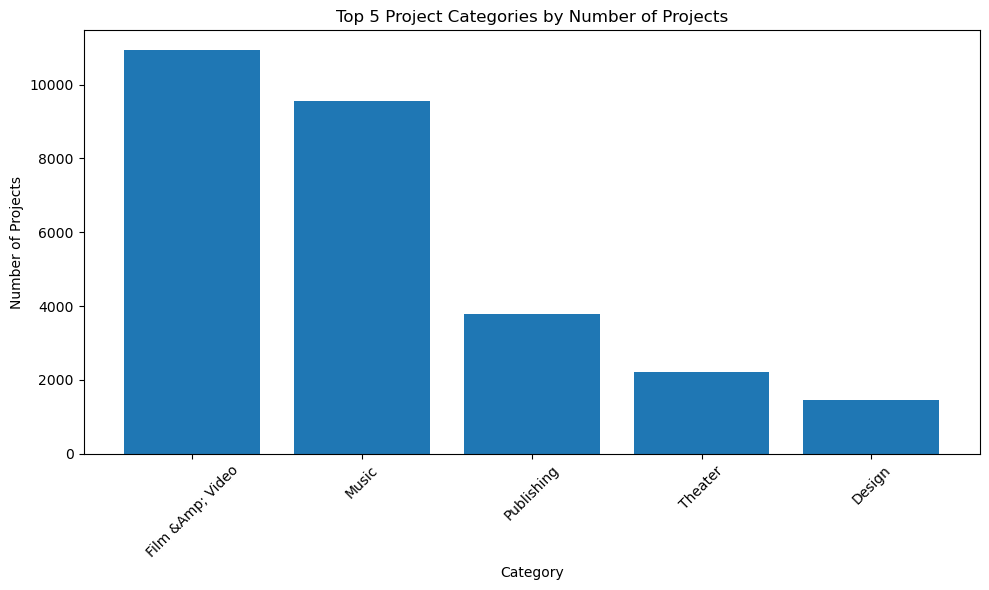

In [19]:
plt.figure(figsize=(10, 6))
categories = [cat for cat, count in top_categories]
counts = [count for cat, count in top_categories]

#print(categories, counts)

plt.bar(categories, counts)
plt.title('Top 5 Project Categories by Number of Projects')
plt.xlabel('Category')
plt.ylabel('Number of Projects')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

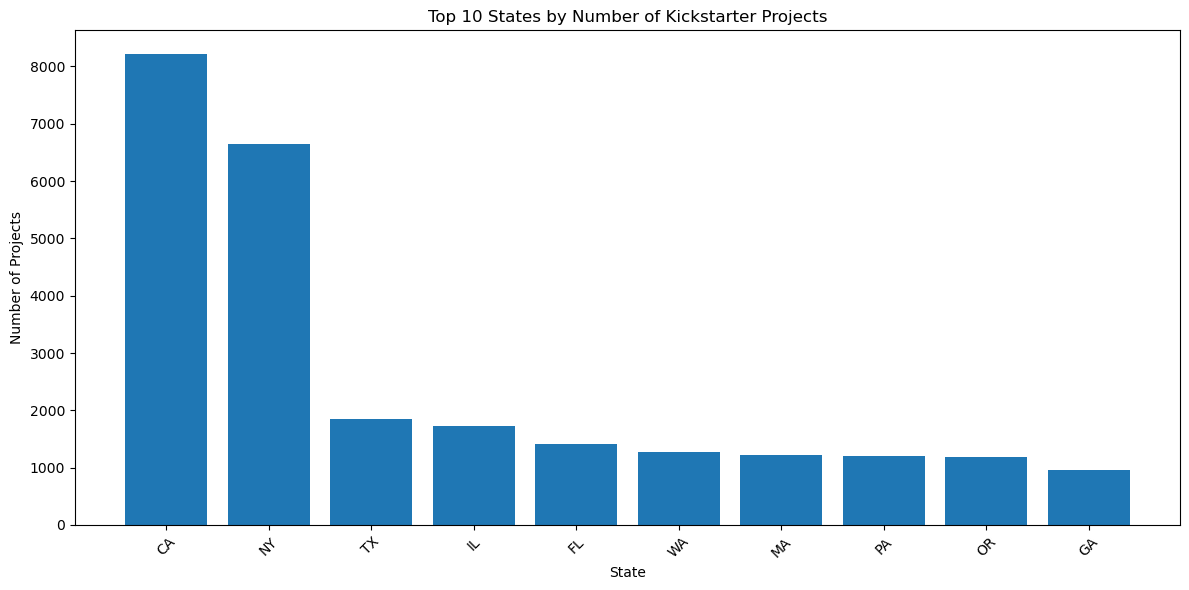

In [20]:
state_counts = {}
for column in df.columns:
    if column.startswith('state_'):
        state_name = column.replace('state_', '')
        count = df[column].sum()
        if count >= 10:  # only include states with 10+ projects
            state_counts[state_name] = count

# Sort states from high to low
sorted_states = sorted(state_counts.items(), key=lambda x: x[1], reverse=True)

top_10_states = sorted_states[:10]
states = [state for state, count in top_10_states]
counts = [count for state, count in top_10_states]

plt.figure(figsize=(12, 6))
plt.bar(states, counts)
plt.title('Top 10 States by Number of Kickstarter Projects')
plt.xlabel('State')
plt.ylabel('Number of Projects')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


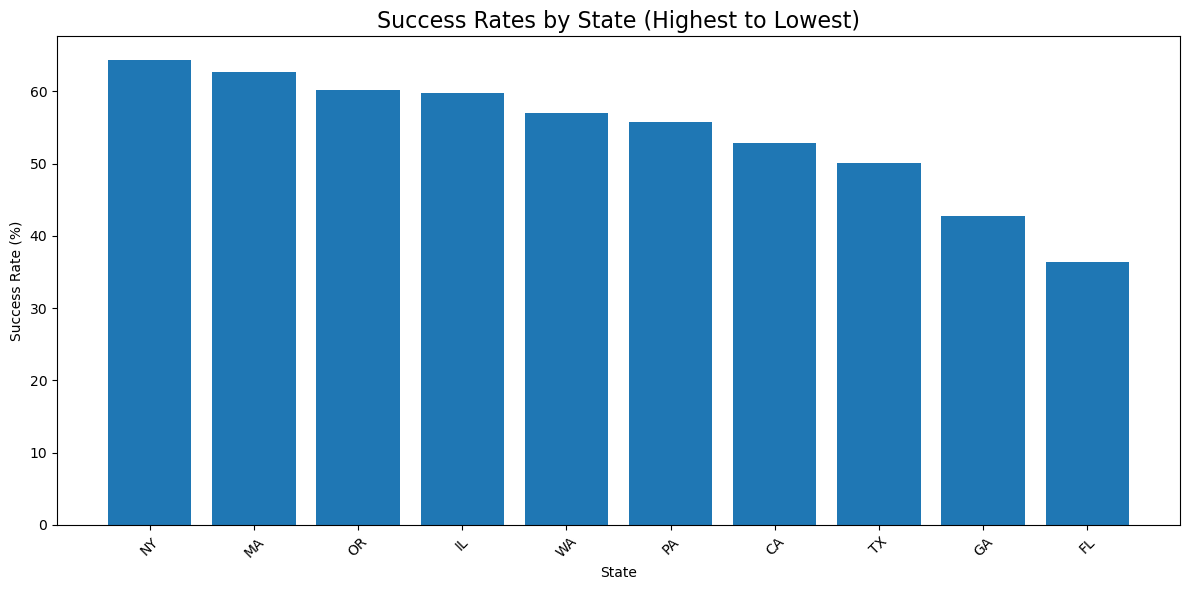

In [21]:
states = []
success_rates = []

for state, total_projects in top_10_states:
    column_name = f'state_{state}'
    state_data = df[df[column_name] == 1]
    successful = (state_data['pledged'] >= state_data['goal']).sum()
    success_rate = (successful / total_projects) * 100
    
    states.append(state)
    success_rates.append(success_rate)

state_df = pd.DataFrame({'State': states, 'Success_Rate': success_rates})
state_df = state_df.sort_values('Success_Rate', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(state_df['State'], state_df['Success_Rate'])
plt.title('Success Rates by State (Highest to Lowest)', fontsize=16)
plt.xlabel('State')
plt.ylabel('Success Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

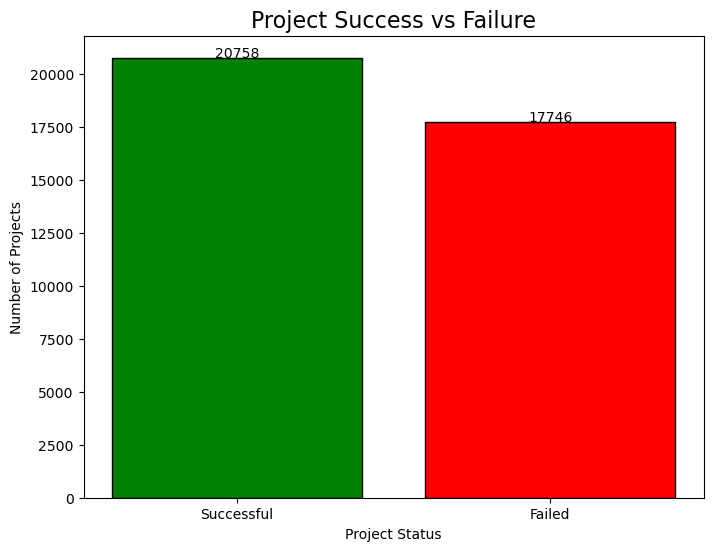

In [22]:
successful = df[df['pledged'] >= df['goal']]
failed = df[df['pledged'] < df['goal']]

plt.figure(figsize=(8, 6))
categories = ['Successful', 'Failed']
counts = [len(successful), len(failed)]

plt.bar(categories, counts, color=['green','red'], edgecolor='black')
plt.title('Project Success vs Failure', fontsize=16)
plt.xlabel('Project Status')
plt.ylabel('Number of Projects')

for i, count in enumerate(counts):
    plt.text(i, count, f'{count}', ha='center')

plt.show()

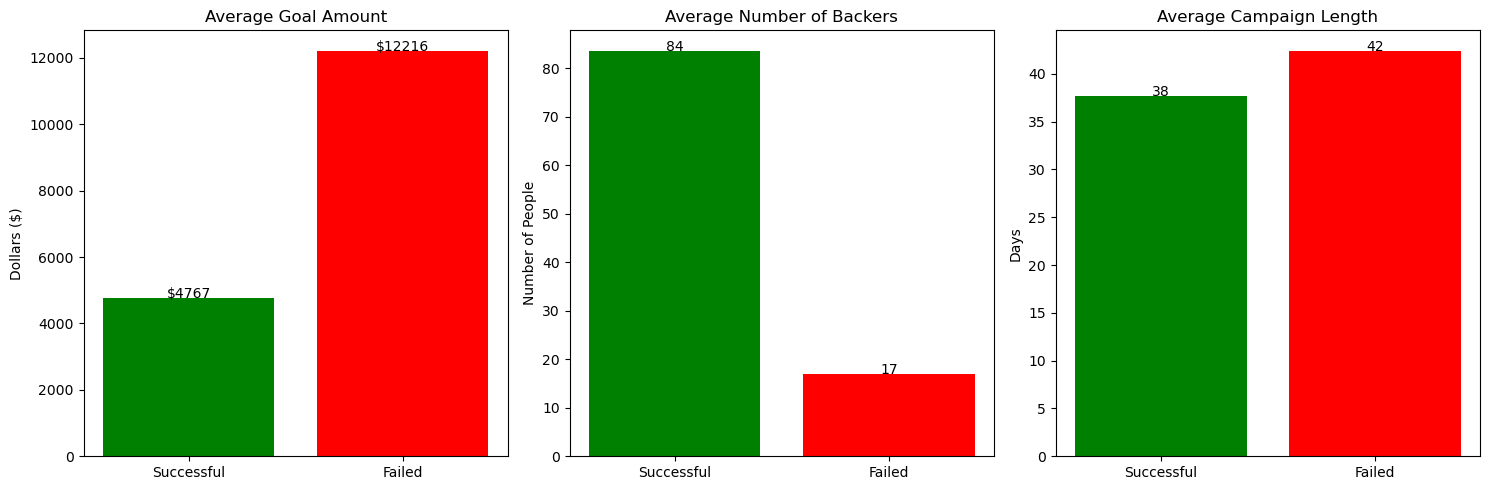

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(['Successful', 'Failed'], 
           [successful['goal'].mean(), failed['goal'].mean()], 
           color=['green', 'red'])
axes[0].set_title('Average Goal Amount')
axes[0].set_ylabel('Dollars ($)')
axes[0].text(0, successful['goal'].mean(), f"${successful['goal'].mean():.0f}", ha='center')
axes[0].text(1, failed['goal'].mean() , f"${failed['goal'].mean():.0f}", ha='center')

axes[1].bar(['Successful', 'Failed'], 
           [successful['backers'].mean(), failed['backers'].mean()], 
           color=['green', 'red'])
axes[1].set_title('Average Number of Backers')
axes[1].set_ylabel('Number of People')
axes[1].text(0, successful['backers'].mean(), f"{successful['backers'].mean():.0f}", ha='center')
axes[1].text(1, failed['backers'].mean(), f"{failed['backers'].mean():.0f}", ha='center')

axes[2].bar(['Successful', 'Failed'], 
           [successful['duration'].mean(), failed['duration'].mean()], 
           color=['green', 'red'])
axes[2].set_title('Average Campaign Length')
axes[2].set_ylabel('Days')
axes[2].text(0, successful['duration'].mean(), f"{successful['duration'].mean():.0f}", ha='center')
axes[2].text(1, failed['duration'].mean(), f"{failed['duration'].mean():.0f}", ha='center')

plt.tight_layout()
plt.show()

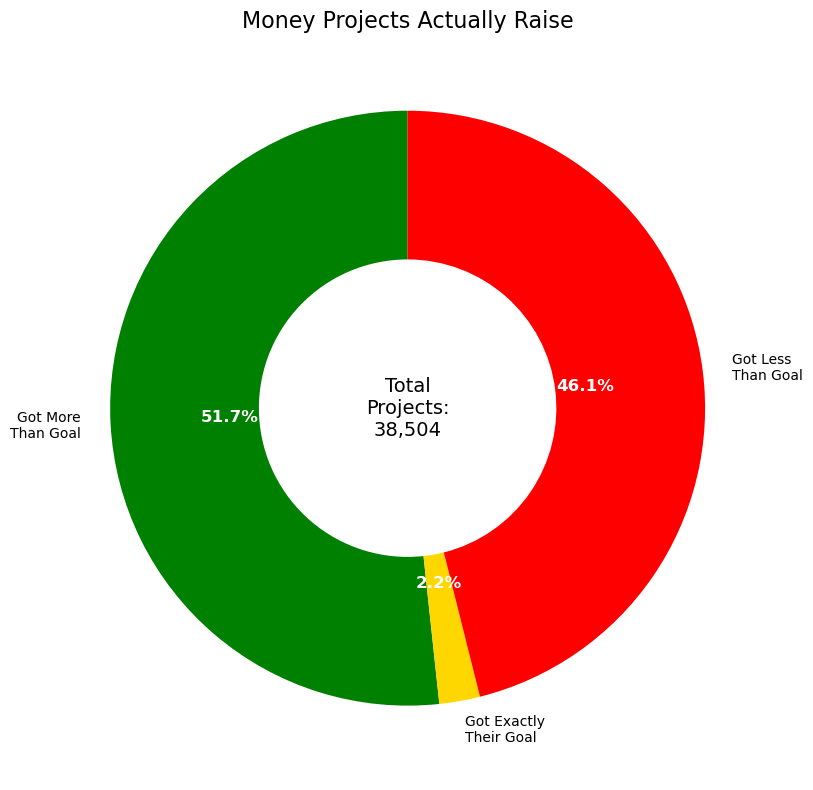

In [24]:
df['funding_ratio'] = df['pledged'] / df['goal']

got_more = len(df[df['funding_ratio'] > 1.0])
got_exactly = len(df[df['funding_ratio'] == 1.0])
got_less = len(df[df['funding_ratio'] < 1.0])

labels = ['Got More\nThan Goal', 'Got Exactly\nTheir Goal', 'Got Less\nThan Goal']
counts = [got_more, got_exactly, got_less]
colors = ['green', 'gold', 'red']

plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', 
                                  startangle=90, wedgeprops=dict(width=0.5))

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.title('Money Projects Actually Raise', fontsize=16)
total_projects = sum(counts)
plt.text(0, 0, f'Total\nProjects:\n{total_projects:,}', ha='center', va='center', 
         fontsize=14)

plt.tight_layout()
plt.show()